In [1]:
%cd ..

/Users/rubenmarcus/Desktop/Code/Personal Projects/Deep Hedging/deep_hedging


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from src.models.heston import simulate_heston
from src.derivatives.european_call import black_scholes_call, black_scholes_delta
from src.strategies.delta_hedge import run_delta_hedge
from src.strategies.neural_hedge import NeuralHedge
from src.portfolio import run_hedge_torch
from src.train import fit
from src.metrics import mse_hedging_loss

In [3]:
SEED = 123
MODEL_SEED = 456

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

DTYPE = torch.float32

print("device:", device)

device: mps


In [4]:
# experiment params

S0 = 100.0
K = 100.0

r = 0.0
T = 1.0

v0 = 0.20**2
theta = 0.20**2

kappa = 2.0
xi = 0.40
rho = -0.70

transaction_cost_rate = 0.0

n_steps = 52


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 1024

n_epochs = 50

learning_rate = 1e-3

In [5]:
sigma_bs = np.sqrt(v0)
print(sigma_bs)

0.2


In [6]:
train_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123
)

val_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456
)

test_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789
)

print(train_sim_np.spot.shape)
print(train_sim_np.variance.shape)

assert np.all(train_sim_np.spot > 0)
assert np.all(train_sim_np.variance >= 0)

(50000, 53)
(50000, 53)


In [7]:
n_pricing = 100_000

pricing_spot_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_pricing,
    r=r,
    seed=999
).spot

pricing_payoff = np.maximum(pricing_spot_np[:, -1] - K, 0.0)
heston_premium = np.exp(-r * T) * np.mean(pricing_payoff)

print("monte carlo heston premium:", heston_premium)

bs_premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=sigma_bs,
    T=T,
    r=r
)

print("BS premium:", bs_premium)
print("difference:", heston_premium - bs_premium)

del pricing_spot_np

monte carlo heston premium: 7.4304253874414865
BS premium: 7.965567455405804
difference: -0.5351420679643173


In [8]:
train_spot = torch.tensor(train_sim_np.spot, dtype=DTYPE)
train_var = torch.tensor(train_sim_np.variance, dtype=DTYPE)

val_spot = torch.tensor(val_sim_np.spot, dtype=DTYPE)
val_var = torch.tensor(val_sim_np.variance, dtype=DTYPE)

test_spot = torch.tensor(test_sim_np.spot, dtype=DTYPE)
test_var = torch.tensor(test_sim_np.variance, dtype=DTYPE)

train_dataset = TensorDataset(train_spot, train_var)
val_dataset = TensorDataset(val_spot, val_var)
test_dataset = TensorDataset(test_spot, test_var)

In [9]:
def make_loaders(seed=SEED):
    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [10]:
def make_run_batch(use_variance):
    def run_batch(model, batch):
        spot_paths, variance_paths = batch

        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = variance_paths.to(device=device, dtype=DTYPE)

        if use_variance:
            policy_variance = variance_paths
        else:
            policy_variance = torch.full_like(variance_paths, theta)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=policy_variance,
            K=K,
            T=T,
            premium=heston_premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate
        )

        return result["pnl"]

    return run_batch

In [11]:
def make_model():
    torch.manual_seed(MODEL_SEED)
    model = NeuralHedge(hidden_dim=64)

    return model.to(device)

In [12]:
train_loader, val_loader, _ = make_loaders()
model_no_var = make_model()

optimizer_no_var = torch.optim.Adam(model_no_var.parameters(), lr=learning_rate)

run_batch_no_var = make_run_batch(use_variance=False)

history_no_var = fit(
    model=model_no_var,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_no_var,
    loss_fn=mse_hedging_loss,
    run_batch=run_batch_no_var,
    n_epochs=n_epochs
)

history_no_var = pd.DataFrame(history_no_var)

In [13]:
train_loader, val_loader, _ = make_loaders()
model_with_var = make_model()

optimizer_with_var = torch.optim.Adam(model_with_var.parameters(), lr=learning_rate)

run_batch_with_var = make_run_batch(use_variance=True)

history_with_var = fit(
    model=model_with_var,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_with_var,
    loss_fn=mse_hedging_loss,
    run_batch=run_batch_with_var,
    n_epochs=n_epochs
)

history_with_var = pd.DataFrame(history_with_var)

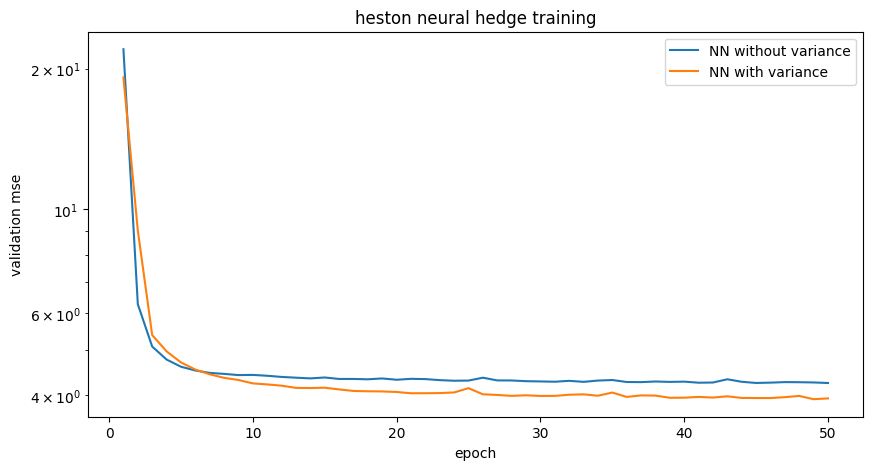

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_no_var["epoch"],
    history_no_var["val_loss"],
    label="NN without variance"
)

plt.plot(
    history_with_var["epoch"],
    history_with_var["val_loss"],
    label="NN with variance"
)

plt.yscale("log")

plt.xlabel("epoch")
plt.ylabel("validation mse")
plt.title("heston neural hedge training")

plt.legend()
plt.show()

In [15]:
@torch.no_grad()
def collect_neural_pnl(
    model,
    loader,
    use_variance
):
    model.eval()

    pnl_batches = []

    for spot_paths, variance_paths in loader:
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = variance_paths.to(device=device, dtype=DTYPE)

        if use_variance:
            policy_variance = variance_paths
        else:
            policy_variance = torch.full_like(variance_paths, theta)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=policy_variance,
            K=K,
            T=T,
            premium=heston_premium,
            r=r,
            transaction_cost_rate=0.0
        )

        pnl_batches.append(result["pnl"].cpu())

    return torch.cat(pnl_batches).numpy()

In [16]:
_, _, test_loader = make_loaders()

nn_no_var_pnl = collect_neural_pnl(
    model=model_no_var,
    loader=test_loader,
    use_variance=False
)

nn_with_var_pnl = collect_neural_pnl(
    model=model_with_var,
    loader=test_loader,
    use_variance=True
)

In [17]:
bs_result = run_delta_hedge(
    stock_paths=test_sim_np.spot,
    K=K,
    sigma=sigma_bs,
    T=T,
    r=r,
    transaction_cost_rate=0.0,
    record_history=False,
    initial_premium=heston_premium
)

bs_pnl = bs_result["pnl"]

In [18]:
def pnl_metrics(pnl):
    pnl = np.asarray(pnl)

    return {
        "mean_pnl": np.mean(pnl),
        "std_pnl": np.std(pnl, ddof=1),
        "rmse": np.sqrt(np.mean(pnl**2)),
        "q05": np.quantile(pnl, 0.05),
        "q01": np.quantile(pnl, 0.01)
    }

In [20]:
comparison = pd.DataFrame({
    "BS fixed-vol delta": pnl_metrics(bs_pnl),
    "NN without variance": pnl_metrics(nn_no_var_pnl),
    "NN with variance": pnl_metrics(nn_with_var_pnl),
}).T

comparison

,mean_pnl,std_pnl,rmse,q05,q01
BS fixed-vol delta,0.008785,2.160468,2.160465,-3.672438,-6.330398
NN without variance,0.012270,2.064442,2.064458,-3.557803,-6.140122
NN with variance,0.015035,1.988341,1.988378,-3.565088,-5.651939


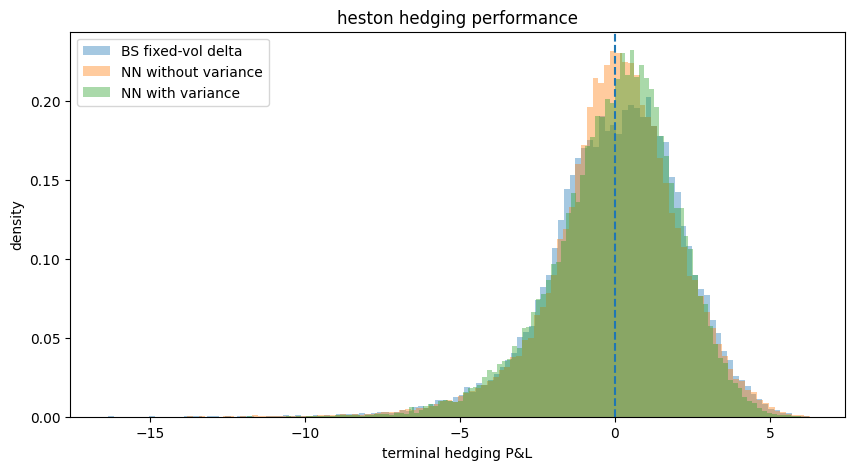

In [26]:
plt.figure(figsize=(10, 5))

plt.hist(
    bs_pnl,
    bins=120,
    density=True,
    alpha=0.4,
    label="BS fixed-vol delta"
)

plt.hist(
    nn_no_var_pnl,
    bins=120,
    density=True,
    alpha=0.4,
    label="NN without variance"
)

plt.hist(
    nn_with_var_pnl,
    bins=120,
    density=True,
    alpha=0.4,
    label="NN with variance"
)

plt.axvline(0.0, linestyle="--")

plt.xlabel("terminal hedging P&L")
plt.ylabel("density")
plt.title("heston hedging performance")

plt.legend()
plt.show()

In [ ]:
variance_grid = torch.linspace(0.05**2, 0.60**2, 300, device=device)

S_eval = 100.0
t_eval = 0.5
previous_position = 0.5

In [28]:
def policy_vs_variance(model, use_variance):
    with torch.no_grad():
        log_moneyness = torch.full_like(variance_grid, np.log(S_eval / K))

        if use_variance:
            variance_feature = variance_grid / theta
        else:
            variance_feature = torch.ones_like(variance_grid)

        tau_feature = torch.full_like(variance_grid, (T - t_eval) / T)

        inventory_feature = torch.full_like(variance_grid, previous_position)

        state = torch.stack([
            log_moneyness,
            variance_feature,
            tau_feature,
            inventory_feature
        ], dim=1)

        target = model(state)

    return target.cpu().numpy()

In [29]:
vol_grid = torch.sqrt(variance_grid).cpu().numpy()

no_var_target = policy_vs_variance(model_no_var, use_variance=False)
with_var_target = policy_vs_variance(model_with_var, use_variance=True)

: 

: 

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    vol_grid,
    no_var_target,
    label="NN without variance"
)

plt.plot(
    vol_grid,
    with_var_target,
    label="NN with variance"
)

plt.xlabel("current instantaneous volatility")
plt.ylabel("target shares")
plt.title("learned hedge response to stochastic volatility")

plt.legend()
plt.show()